In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from skimage.transform import resize
import random
import os
from PIL import Image
import pandas as pd
import math
from matplotlib.image import imread

print("Done importing libraries\n")

Done importing libraries



### Preprocessing: Linear Contrast Stretching
#### (Applied after the Median and Gaussian filters)

In [2]:
def linear_contrast_stretching(image):
    img = image.copy()
    #Store the min and max intensity in the grayscale dog image.
    min_intensity = np.min(img)  
    max_intensity = np.max(img)  

    linear_contrast_stretched_image = img.copy()
    denominator = max_intensity - min_intensity
    if denominator != 0:  #We can't divide by zero!
        return (img - min_intensity) * (255 / denominator)  #Apply the linear contrast stretching formula.
    else:
        print("Cannot apply linear contrast stretching because all pixel intensities are the same. Please try with a different image.")

print("Defined linear contrast stretching function")

Defined linear contrast stretching function


### Preprocessing: Running the Sobel Operator on Median_Gaussian_Filtered_Images

In [3]:
if not os.path.exists("sobel_median_gaussian_images"):
    os.makedirs("sobel_median_gaussian_images")
    print(f"Created folder: sobel_median_gaussian_images")
else:
    print(f"Folder sobel_median_gaussian_images already exists.")
    
print("Operating Sobel on 10 Images\n")
for i in range(1, 11):
    print("Enhancing Image " + str(i))
    #gaussian filter -> save the result to median_gaussian_filtered_images folder
    current_image = imread("median_gaussian_filtered_images/median_gaussian_img_" + str(i) + ".jpg")
    stretch_result = linear_contrast_stretching(current_image)
    res_img = Image.fromarray(stretch_result)
    res_img.convert("L").save(f"sobel_median_gaussian_images/sobel_median_gaussian_img_{i}.jpg")

Folder sobel_median_gaussian_images already exists.
Operating Sobel on 10 Images

Enhancing Image 1
Enhancing Image 2
Enhancing Image 3
Enhancing Image 4
Enhancing Image 5
Enhancing Image 6
Enhancing Image 7
Enhancing Image 8
Enhancing Image 9
Enhancing Image 10


### Define Otsu Thresholding Function

In [3]:
def otsu(image):
    # First compute the histogram
    histogram, bin_edges = np.histogram(image.flatten(), bins=256, range=(0, 255))
    
    probabilities = histogram / image.size

    # t is the intensity values (0 to 255)
    # ω(t) aka prob_class1
    #prob_class2 = 1 - prob_class1
    cumulative_sum = np.cumsum(probabilities)
    # μ(t) = i * p(i)
    cumulative_mean = np.cumsum(probabilities * np.arange(256))

    #last value of cumulative mean
    global_mean_intensity = cumulative_mean[-1]

    
    denominator = cumulative_sum * (1 - cumulative_sum)

    # Only compute variance where denominator is non-zero. (Can't divide by 0)
    # this is a mask
    valid = denominator > 0
    between_class_variance = np.zeros(256)
    between_class_variance[valid] = (global_mean_intensity * cumulative_sum[valid] - cumulative_mean[valid]) ** 2 / \
                                     denominator[valid]

    threshold = np.argmax(between_class_variance)
    return threshold



### Functions to apply Thresholds to binarize an image

In [2]:
def apply_threshold(image, threshold):
    img = image.copy() 
    one = img >= threshold
    zero = img < threshold
    img[one] = 255
    img[zero] = 0
    return img

In [4]:
def apply_multiple_thresholds(image, thresholds):
    result = np.zeros_like(image)
    thresholds = sorted(thresholds)
    thresholds.append(256)  #Upper bound for the last region
    lower = 0
    for i in range(len(thresholds)):
        upper = thresholds[i]
        mask = (image >= lower) & (image < upper)
        result[mask] = i * (255 // (len(thresholds) - 1))
        lower = upper

    return result


### Helper function to plot histogram of an image

In [5]:
def plot_histogram(image, filename, image_number):
    plt.figure()
    plt.hist(image.flatten(), bins=256, range=(0, 255), color="steelblue")
    plt.xlabel("Intensity")
    plt.ylabel("Count")

    plt.title(f"Grayscale Histogram - Image {image_number}")
    plt.savefig(filename)
    plt.show()

### Generate and save histograms for each image

Folder histograms_of_filtered_images already exists.
Creating 10 Histograms

Creating Histogram for Image 1


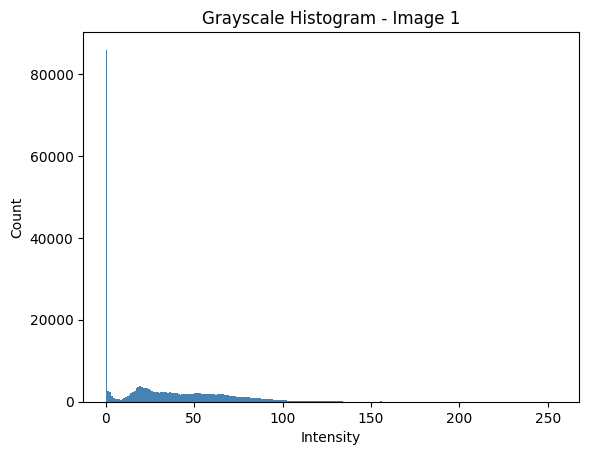

Creating Histogram for Image 2


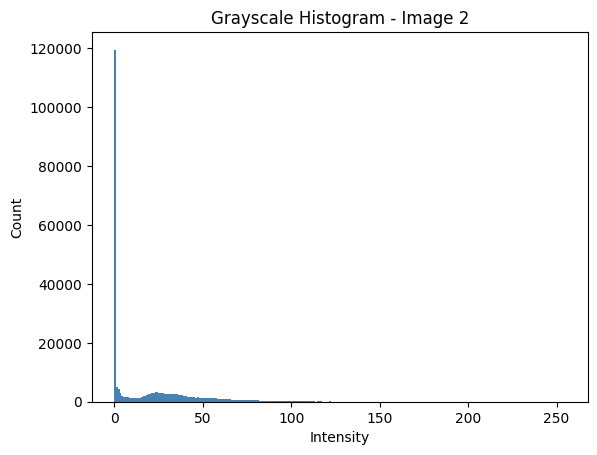

Creating Histogram for Image 3


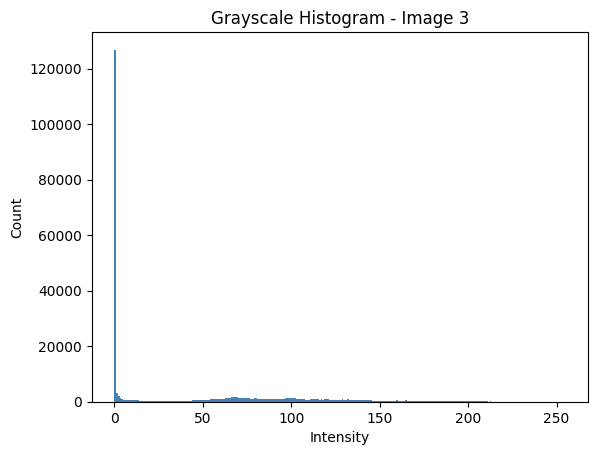

Creating Histogram for Image 4


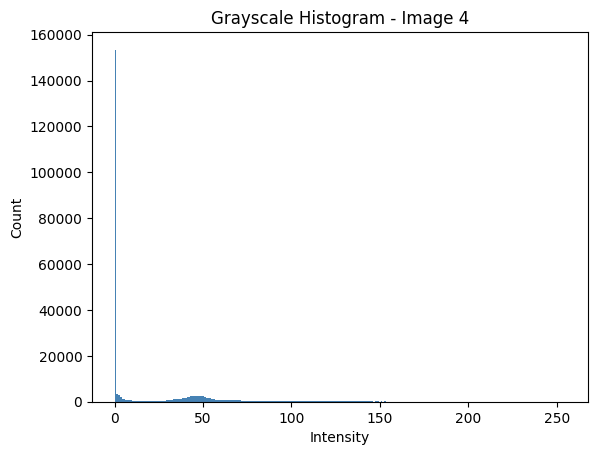

Creating Histogram for Image 5


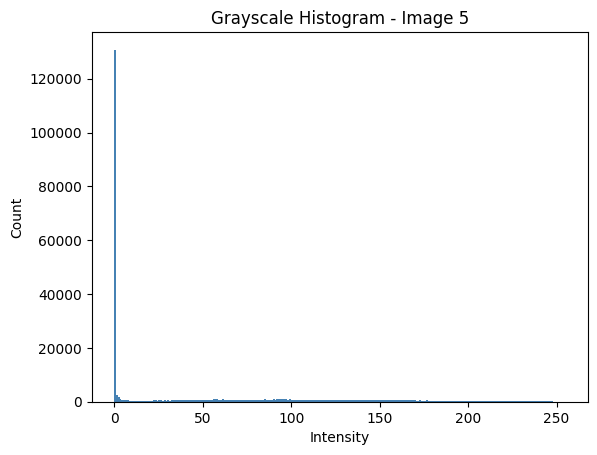

Creating Histogram for Image 6


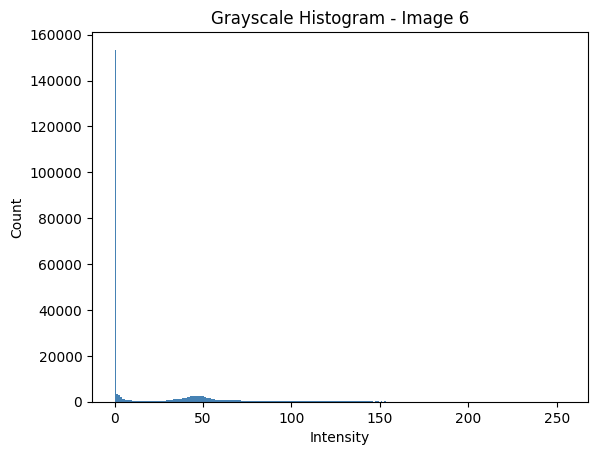

Creating Histogram for Image 7


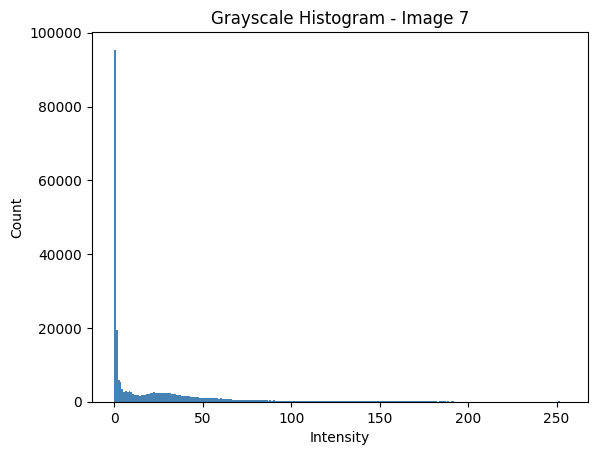

Creating Histogram for Image 8


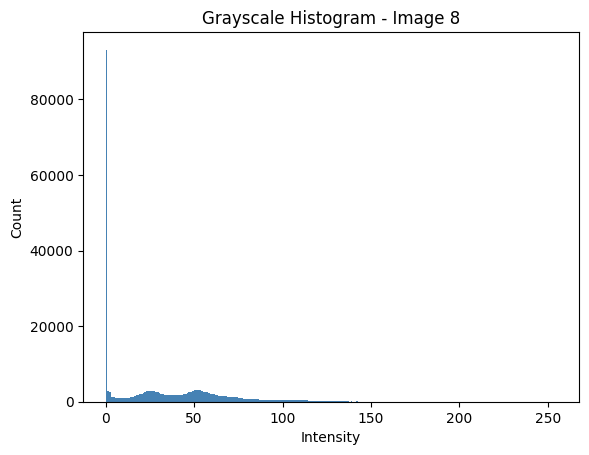

Creating Histogram for Image 9


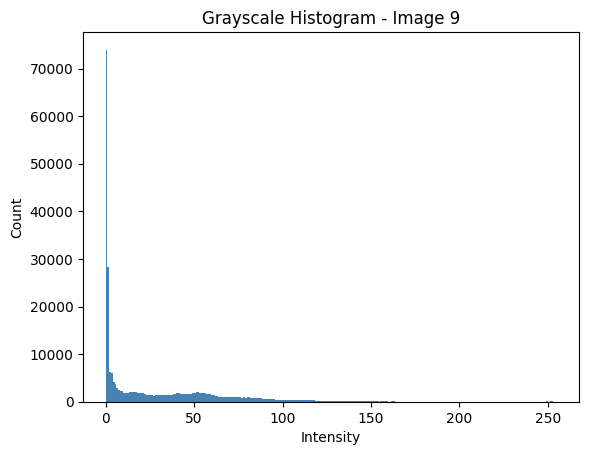

Creating Histogram for Image 10


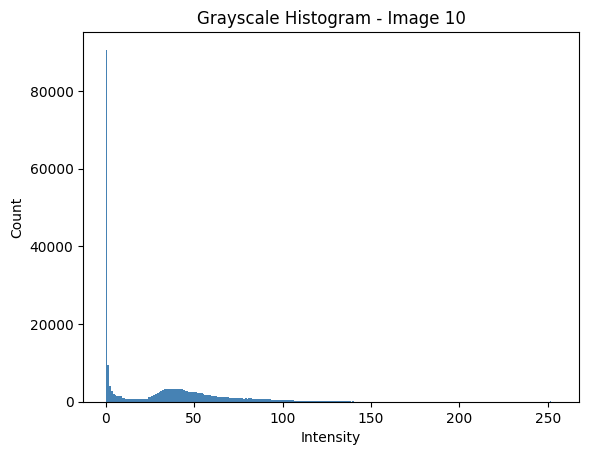

Done creating histograms!


In [9]:
if not os.path.exists("histograms_of_filtered_images"):
    os.makedirs("histograms_of_filtered_images")
    print(f"Created folder: histograms_of_filtered_images")
else:
    print(f"Folder histograms_of_filtered_images already exists.")

print("Creating 10 Histograms\n")
for i in range(1, 11):
    print("Creating Histogram for Image " + str(i))
    sobel_filepath = "sobel_median_gaussian_images"
    current_image = imread(f"{sobel_filepath}/sobel_median_gaussian_img_{i}.jpg")
    plot_histogram(current_image, f"histograms_of_filtered_images/histogram_{i}.png", i)

print("Done creating histograms!")

### Apply Otsu Thresholding to each image

In [17]:
otsu_thresholds = []
image_dir = "sobel_median_gaussian_images"
image_name = "sobel_median_gaussian_img_"

if not os.path.exists("otsu_images"):
    os.makedirs("otsu_images")
    print(f"Created folder: otsu_images")
else:
    print(f"Folder otsu_images already exists.")
    
print("Otsu Thresholding 10 Images\n")
for i in range(1, 11):
    print("Thresholding Image " + str(i))
    #otsu thresholding -> save the result to otsu_images folder
    current_image = imread(f"{image_dir}/{image_name}{i}.jpg")
    t = otsu(current_image)
    otsu_thresholds.append(int(t))
    binary_image = (current_image > t).astype(np.uint8) * 255
    res_img = Image.fromarray(binary_image)
    res_img.convert("L").save(f"otsu_images/otsu_img_{i}.jpg")

print("\nThe Otsu thresholds for the 10 images are: ", otsu_thresholds)

Folder otsu_images already exists.
Otsu Thresholding 10 Images

Thresholding Image 1
Thresholding Image 2
Thresholding Image 3
Thresholding Image 4
Thresholding Image 5
Thresholding Image 6
Thresholding Image 7
Thresholding Image 8
Thresholding Image 9
Thresholding Image 10

The Otsu thresholds for the 10 images are:  [39, 30, 57, 37, 74, 37, 58, 37, 42, 34]


### Manual Thresholding (Single & Multi level)

In [ ]:
multiple_thresholds = [5,45]
single_threshold = int(np.average(otsu_thresholds))

print("The single threshold is the average of the Otsu thresholds: ", single_threshold,"\n")
image_dir = "sobel_median_gaussian_images"
image_name = "sobel_median_gaussian_img_"

if not os.path.exists("single_threshold_images"):
    os.makedirs("single_threshold_images")
    print(f"Created folder: single_threshold_images")
else:
    print(f"Folder single_threshold_images already exists.")

if not os.path.exists("multiple_threshold_images"):
    os.makedirs("multiple_threshold_images")
    print(f"Created folder: multiple_threshold_images")
else:
    print(f"Folder multiple_threshold_images already exists.")
    
print("\nManually Thresholding 10 Images\n")
for i in range(1, 11):
    print("Thresholding Image " + str(i))
    #manual thresholding -> save the result to single_threshold_images folder
    current_image = imread(f"{image_dir}/{image_name}{i}.jpg")
    single_result = apply_threshold(current_image, single_threshold)
    multiple_result = apply_multiple_thresholds(current_image, multiple_thresholds)
    
    res_img = Image.fromarray(binary_image)
    res_img.convert("L").save(f"otsu_images/otsu_img_{i}.jpg")

The single threshold is the average of the Otsu thresholds:  44.5 

Folder single_threshold_images already exists.
Folder multiple_threshold_images already exists.

Manually Thresholding 10 Images

Thresholding Image 1
Thresholding Image 2
Thresholding Image 3
Thresholding Image 4
Thresholding Image 5
Thresholding Image 6
Thresholding Image 7
Thresholding Image 8
Thresholding Image 9
Thresholding Image 10
